In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as stats

from sim.simulation import DataGen
from sim.sim_plots import plotTermStructure, plotYield
from pricing.pricer import PricerClass
from calibration import Calibration

In [2]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 40, 50])

To do:
1. Show changes in the forward/spot curves when any of $r_t, m_t, l_t$ change
2. Show changes in the forward/spot curves when any of $\alpha ,\sigma, \mu$ change

In [25]:
baseParams = dict(
    alpha_r = 1.0547, alpha_m = 0.6358, alpha_l = 0.0165,
    sigma_m = 109.2/10000, sigma_l = 96.4/10000,
    rho = 0.2,
    mu = 10.055/100,
)

pricer = PricerClass(**baseParams)

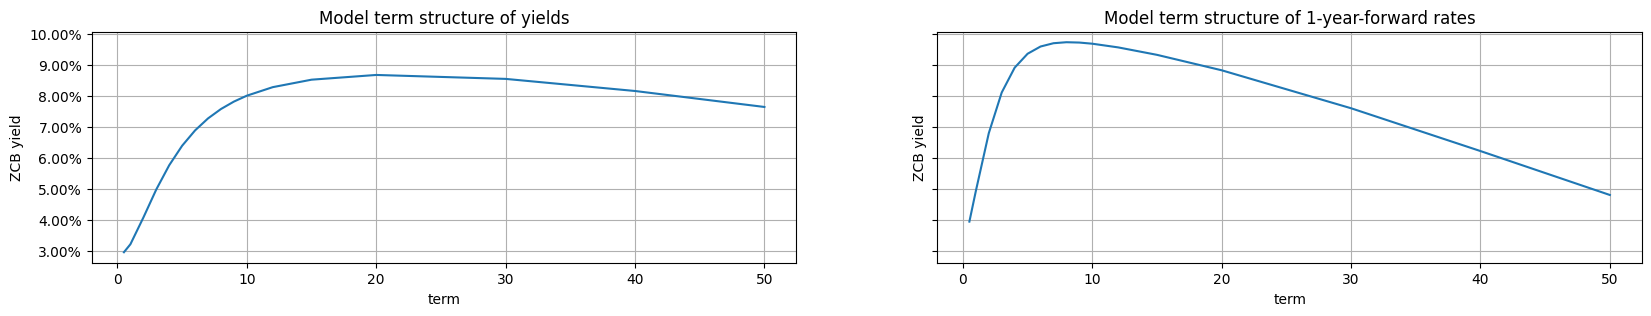

In [44]:
baseFactors = [0.03, 0.02, 0.1]
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 3), sharey=True)
ax[0].plot(MATURITIES, pricer.termStructure(MATURITIES, baseFactors))
ax[0].set_title('Model term structure of yields')
ax[0].set_xlabel('term')
ax[0].set_ylabel('ZCB yield')
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2%}'))
ax[0].grid(True)

ax[1].plot(MATURITIES, pricer.forwardTermStructure(deltaTau = 1, maturities= MATURITIES, factors= baseFactors))
ax[1].set_title('Model term structure of 1-year-forward rates')
ax[1].set_xlabel('term')
ax[1].set_ylabel('ZCB yield')
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2%}'))
ax[1].grid(True)

array([0., 0., 0., 0., 0., 0., 0.])

In [121]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['sigma_l'] = +30/10000
stressParams = {key: baseParams[key] + stressEffects[key] for key in baseParams}

Text(0, 0.5, 'Parameter change')

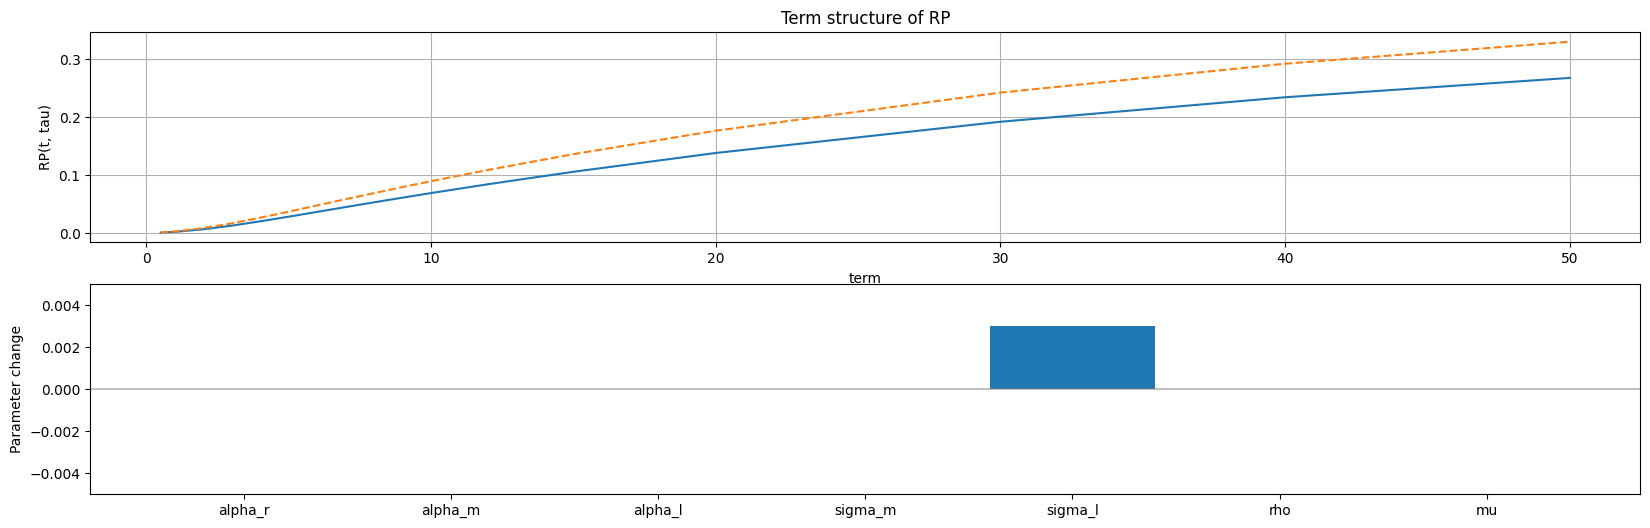

In [122]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['sigma_l'] = +30/10000
stressParams = {key: baseParams[key] + stressEffects[key] for key in baseParams}

stressedPricer = PricerClass(**stressParams)

str_diff = np.array([x for x in stressEffects.values()])

amtOfRisk_termStructure = np.array([pricer.amountOfRisk(tau = x, deltaTau = 1) for x in MATURITIES])
amtOfRisk_termStructure_str = np.array([stressedPricer.amountOfRisk(tau = x, deltaTau = 1) for x in MATURITIES])
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (20, 6))
ax[0].plot(MATURITIES, amtOfRisk_termStructure)
ax[0].plot(MATURITIES, amtOfRisk_termStructure_str, linestyle = '--')
ax[0].set_title('Term structure of RP')
ax[0].set_xlabel('term')
ax[0].set_ylabel('RP(t, tau)')
ax[0].grid(True)

ax[1].bar([x for x in stressParams.keys()], str_diff)
ax[1].axhline(y = 0, color = 'grey', alpha = 0.5)
ax[1].set_ylim(-0.005, + 0.005)
ax[1].set_ylabel('Parameter change')


Text(0, 0.5, 'Parameter change')

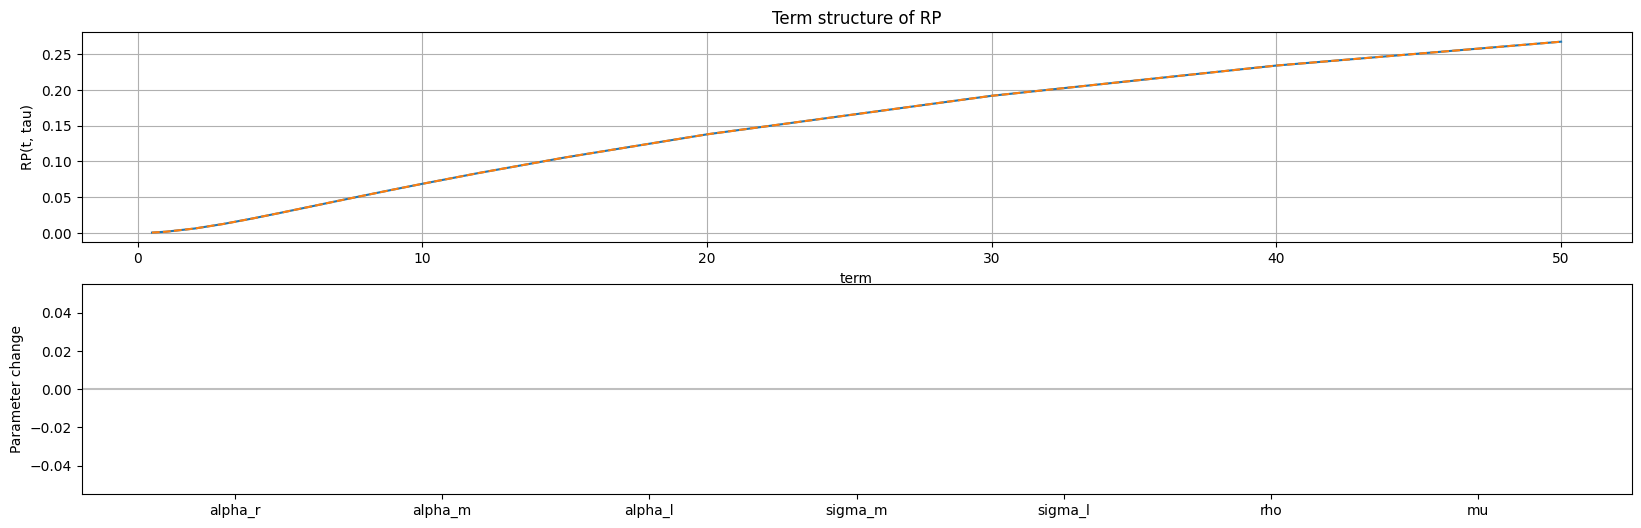

In [116]:
stressParams = dict(
    alpha_r = baseParams['alpha_r'], alpha_m = baseParams['alpha_m'], alpha_l = baseParams['alpha_l'],
    sigma_m = baseParams['sigma_m'], sigma_l = baseParams['sigma_l'],
    rho = baseParams['rho'],
    mu = baseParams['mu'],
)

stressedPricer = PricerClass(**stressParams)

str_diff = np.array([x for x in stressParams.values()]) - np.array([x for x in baseParams.values()])

amtOfRisk_termStructure = np.array([pricer.amountOfRisk(tau = x, deltaTau = 1) for x in MATURITIES])
amtOfRisk_termStructure_str = np.array([stressedPricer.amountOfRisk(tau = x, deltaTau = 1) for x in MATURITIES])
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (20, 6))
ax[0].plot(MATURITIES, amtOfRisk_termStructure)
ax[0].plot(MATURITIES, amtOfRisk_termStructure_str, linestyle = '--')
ax[0].set_title('Term structure of RP')
ax[0].set_xlabel('term')
ax[0].set_ylabel('RP(t, tau)')
ax[0].grid(True)

ax[1].bar([x for x in stressParams.keys()], str_diff)
ax[1].axhline(y = 0, color = 'grey', alpha = 0.5)
# ax[1].set_ylim(-0.005, + 0.005)
ax[1].set_ylabel('Parameter change')
